In [1]:
import json
from tqdm import tqdm
from pathlib import Path

import copy
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset

device = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [2]:
# Root Path
ROOT = Path("Amazon_products")

# Train and Test Dataset
TRAIN_CORPUS_PATH = ROOT / "train" /  "train_corpus.txt"
TEST_CORPUS_PATH = ROOT / "test" / "test_corpus.txt"

# Taxonomy
CLASSES_PATH = ROOT / "classes.txt"
HIERARCHY_PATH = ROOT / "class_hierarchy.txt"
KEYWORDS_PATH = ROOT / "class_related_keywords.txt"

In [3]:
import matplotlib.pyplot as plt
from collections import defaultdict
import itertools

# ------------------------
# Function for loads
# ------------------------

def load_lines(p: Path):
    with p.open("r", encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f]

def load_pid2text(p: Path):
    """TSV: pid \\t text  -> dict[pid]=text"""
    pid2text = {}
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t", 1)
            if len(parts) == 2:
                pid, text = parts
                pid2text[pid] = text
    return pid2text

def load_classes_int(p: Path):
    class_dict = {}
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            label_int, label_str = line.rstrip("\n").split("\t")
            class_dict[int(label_int)] = label_str
    return class_dict

def load_keywords(p: Path):
    keywords = {}
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            key, items = line.rstrip("\n").split(":")
            item_list = [item for item in items.split(",")]
            keywords[key] = item_list
    return keywords

def load_class_graph(p: Path):
    edges = []
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            p, c = map(int, line.rstrip("\n").split("\t"))
            edges.append((p, c))
    return edges

def load_json(path):
    """Load JSON file into Python object."""
    with open(path) as f:
        return json.load(f)

# ------------------------
# Visualization
# ------------------------

def plot_results(results_dict, split="valid", metric="Loss"):
    """
    Plot metric (e.g., loss) values over epochs for multiple models.

    Args:
        results_dict: dict of dicts
            Example:
                results_dict["valid"]["mlp_partial"] = [0.69, 0.65, ...]
        split: "train" | "valid" | "test"
        metric: name of the metric to display (default: Loss)
    """
    assert split in results_dict, f"{split} not in results_dict"

    plt.figure(figsize=(8, 5))

    for label, value_list in results_dict[split].items():
        plt.plot(
            range(1, len(value_list) + 1),
            value_list,
            marker="o",
            label=label
        )

    plt.title(f"{split.capitalize()} {metric} over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [4]:
# ---------- Read-only loads ----------

train_pid2text    = load_pid2text(TRAIN_CORPUS_PATH)
test_pid2text     = load_pid2text(TEST_CORPUS_PATH)
pid2class         = load_classes_int(CLASSES_PATH)
rel_keywords      = load_keywords(KEYWORDS_PATH)
class_graph_edges = load_class_graph(HIERARCHY_PATH)

NUM_CLASSES = len(pid2class)
print(f"#train={len(train_pid2text):,}  #test={len(test_pid2text):,}")

#train=29,487  #test=19,658


# GAT + MLP training

In [5]:
EMB_PATH = ROOT / "Embeddings"

train_emb_dict = load_json(EMB_PATH / "train_embeddings.json")
test_emb_dict = load_json(EMB_PATH / "test_embeddings.json")
class_emb_dict = load_json(EMB_PATH / "class_embeddings.json")
class_llm_emb_dict = load_json(EMB_PATH / "class_llm_embeddings.json")

train_doc_emb = np.stack(list(train_emb_dict.values()))   # (N_train, D)
test_doc_emb  = np.stack(list(test_emb_dict.values()))    # (N_test, D)
class_name_emb = np.stack(list(class_emb_dict.values()))  # (NUM_CLASSES, D)
class_llm_emb = np.stack(list(class_llm_emb_dict.values()))  # (NUM_CLASSES, D)

In [6]:
Y_silver_df = pd.read_csv("Silver Core/Y_silver.csv")
Y_silver = Y_silver_df.to_numpy(dtype=np.float32)

In [7]:
class EmbeddingDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        assert X.shape[0] == y.shape[0]
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [8]:
dataset = EmbeddingDataset(train_doc_emb, Y_silver)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

g = torch.Generator().manual_seed(42)
train_split, val_split = random_split(dataset, [train_size, val_size], generator=g)

train_loader = DataLoader(train_split, batch_size=32, shuffle=True)
valid_loader = DataLoader(val_split, batch_size=32, shuffle=False)

In [9]:
def build_adj_mask(num_classes, edges, bidir=True, self_loop=True):
    """
    adj_mask[i, j] = True  => class i attends to class j
    """
    adj = torch.zeros((num_classes, num_classes), dtype=torch.bool)
    if self_loop:
        adj.fill_diagonal_(True)

    for p, c in edges:
        adj[c, p] = True          # child -> parent
        if bidir:
            adj[p, c] = True      # parent -> child
    return adj

adj_mask = build_adj_mask(NUM_CLASSES, class_graph_edges).to(device)

In [10]:
class LabelGAT(nn.Module):
    """
    LabelGAT with explicit Q, K, V, O projections (Transformer-style attention).

    __init__(input, output, head, dropout)

    - input  : input embedding dim
    - output : output embedding dim
    - head   : number of attention heads
    - dropout: dropout rate

    Built-in residual + LayerNorm.
    """

    def __init__(self, input: int, output: int, head: int, dropout: float):
        super().__init__()
        assert output % head == 0, "output must be divisible by head"

        self.input = input
        self.output = output
        self.head = head
        self.d_head = output // head
        self.dropout = dropout

        # ===== Q, K, V projections =====
        self.W_q = nn.Linear(input, output, bias=False)
        self.W_k = nn.Linear(input, output, bias=False)
        self.W_v = nn.Linear(input, output, bias=False)

        # ===== Output projection =====
        self.W_o = nn.Linear(output, output, bias=False)

        self.scale = self.d_head ** -0.5

        self.ln = nn.LayerNorm(output)
        self.dropout_layer = nn.Dropout(dropout)

        # init
        nn.init.xavier_uniform_(self.W_q.weight)
        nn.init.xavier_uniform_(self.W_k.weight)
        nn.init.xavier_uniform_(self.W_v.weight)
        nn.init.xavier_uniform_(self.W_o.weight)

    def forward(self, x: torch.Tensor, adj_mask: torch.Tensor):
        """
        x: (C, input)
        adj_mask: (C, C) bool, adj_mask[i, j] = True means j attends to i
        """
        C = x.size(0)
        residual = x

        # ===== Project Q, K, V =====
        Q = self.W_q(x).view(C, self.head, self.d_head)  # (C, H, Dh)
        K = self.W_k(x).view(C, self.head, self.d_head)  # (C, H, Dh)
        V = self.W_v(x).view(C, self.head, self.d_head)  # (C, H, Dh)

        # ===== Scaled dot-product attention =====
        # attn_logits[i, j, h] = <Q_i^h, K_j^h> / sqrt(d_head)
        attn_logits = torch.einsum("ihd,jhd->ijh", Q, K) * self.scale  # (C, C, H)

        # mask non-neighbors
        neg_inf = torch.finfo(attn_logits.dtype).min
        attn_logits = attn_logits.masked_fill(
            ~adj_mask.unsqueeze(-1), neg_inf
        )

        # attention weights
        attn = F.softmax(attn_logits, dim=1)  # over j
        attn = self.dropout_layer(attn)

        # ===== Aggregate values =====
        out = torch.einsum("ijh,jhd->ihd", attn, V)  # (C, H, Dh)
        out = out.reshape(C, self.output)            # (C, output)

        # output projection
        out = self.W_o(out)
        out = self.dropout_layer(out)

        # ===== Residual + Norm =====
        if residual.shape[1] == self.output:
            out = out + residual

        out = self.ln(out)
        return out


In [11]:
class ClassOnlyGAT(nn.Module):
    def __init__(self, d_model, heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            LabelGAT(d_model, d_model, heads, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, adj_mask):
        for layer in self.layers:
            x = layer(x, adj_mask)
        return x

In [12]:
class GATPrototypeClassifier(nn.Module):
    def __init__(
        self,
        init_class_emb,
        adj_mask,
        hidden_dim=768,
        heads=4,
        num_layers=2,
        dropout=0.1,
        temperature=0.1
    ):
        super().__init__()
        self.register_buffer("adj_mask", adj_mask)

        self.class_emb = nn.Parameter(
            torch.tensor(init_class_emb, dtype=torch.float32)
        )

        self.gat = ClassOnlyGAT(
            d_model=hidden_dim,
            heads=heads,
            num_layers=num_layers,
            dropout=dropout
        )

        self.doc_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.temperature = temperature
        self.log_temp = nn.Parameter(torch.zeros(NUM_CLASSES))


    def forward(self, doc_emb):
        doc_h = self.doc_mlp(doc_emb)                  # (B, D)
        class_h = self.gat(self.class_emb, self.adj_mask)  # (C, D)

        doc_h = F.normalize(doc_h, dim=-1)
        class_h = F.normalize(class_h, dim=-1)

        # class-wise temperature
        temp = torch.exp(self.log_temp).unsqueeze(0)  # (1, C)
        logits = (doc_h @ class_h.T) / temp

        return logits

In [13]:
def masked_bce_loss(logits, targets):
    """
    targets: 0/1, -1 means ignore
    """
    mask = (targets >= 0).float()
    loss = F.binary_cross_entropy_with_logits(
        logits,
        targets.clamp(min=0),
        reduction="none"
    )
    loss = (loss * mask).sum() / mask.sum().clamp_min(1.0)
    return loss

In [14]:
model = GATPrototypeClassifier(
    init_class_emb=class_name_emb,
    adj_mask=adj_mask,
    hidden_dim=class_name_emb.shape[1],
    heads=2,
    num_layers=1,
    dropout=0.2,
    temperature=0.1
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-3,
    weight_decay=1e-4
)

In [15]:
import copy

EPOCHS = 30

best_val_loss = 1.0
wait_time = 6
cnt = 0
best_model_state = copy.deepcopy(model.state_dict())

train_losses, valid_losses = [], []

for epoch in range(1, EPOCHS + 1):

    # =========== Train ===========
    model.train()
    total_loss = 0.0
    total_cnt = 0

    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch} [Train]"):
        batch_x = batch_x.to(device)          # (B, D)
        batch_y = batch_y.to(device)          # (B, C)

        optimizer.zero_grad()

        logits = model(batch_x)
        loss = masked_bce_loss(logits, batch_y)

        if loss is None:
            continue

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_cnt  += 1

    avg_train_loss = total_loss / max(total_cnt, 1)
    train_losses.append(avg_train_loss)

    # ========== Validation ==========
    model.eval()
    total_vloss = 0.0
    total_vcnt  = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = masked_bce_loss(logits, batch_y)

            if loss is None:
                continue

            total_vloss += loss.item()
            total_vcnt  += 1


    avg_val_loss = total_vloss / max(total_vcnt, 1)
    valid_losses.append(avg_val_loss)

    print(
        f"[Epoch {epoch:03d}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    # ========== Early Stopping ==========
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        cnt = 0
    else:
        cnt += 1
        if cnt >= wait_time:
            print(f"No improvement in val loss for {cnt} epochs. Early stopping.")
            break

model.load_state_dict(best_model_state)
print(f"Best validation loss: {best_val_loss:.4f}")


Epoch 1 [Train]: 100%|██████████| 830/830 [00:03<00:00, 262.94it/s]


[Epoch 001] Train Loss: 0.1561 | Val Loss: 0.0581


Epoch 2 [Train]: 100%|██████████| 830/830 [00:02<00:00, 289.84it/s]


[Epoch 002] Train Loss: 0.0471 | Val Loss: 0.0390


Epoch 3 [Train]: 100%|██████████| 830/830 [00:03<00:00, 262.00it/s]


...

[Epoch 019] Train Loss: 0.0068 | Val Loss: 0.0099


Epoch 20 [Train]: 100%|██████████| 830/830 [00:06<00:00, 120.65it/s]


[Epoch 020] Train Loss: 0.0065 | Val Loss: 0.0107


Epoch 21 [Train]: 100%|██████████| 830/830 [00:06<00:00, 120.92it/s]


[Epoch 021] Train Loss: 0.0065 | Val Loss: 0.0100
No improvement in val loss for 6 epochs. Early stopping.
Best validation loss: 0.0097


In [16]:
results_dict = {'losses':{}}

results_dict['losses']['train'] = train_losses[:]
results_dict['losses']['valid'] = valid_losses[:]

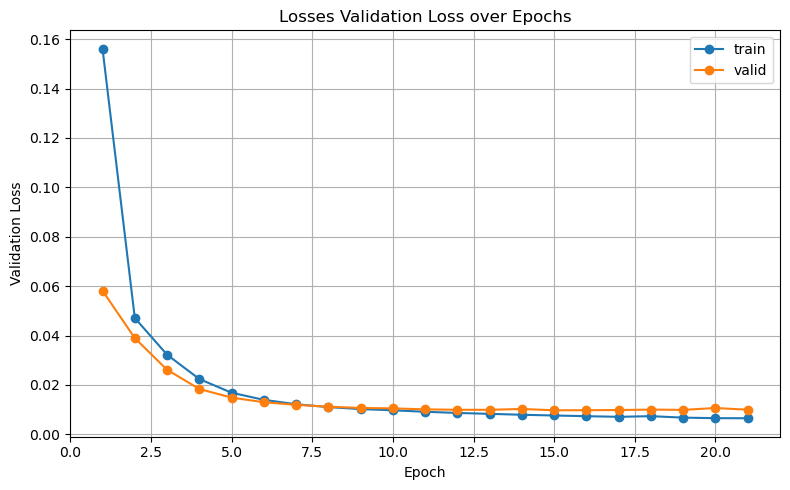

In [17]:
plot_results(results_dict, split="losses", metric="Validation Loss")

In [18]:
model.eval()
with torch.no_grad():
    test_x = torch.from_numpy(test_doc_emb).float().to(device)
    test_logits = model(test_x)
    test_probs = torch.sigmoid(test_logits).cpu().numpy()   # (N_test, NUM_CLASSES)

TOP_K_PRED = 3
THRESHOLD = 0.0

topk_indices = np.argsort(-test_probs, axis=1)[:, :TOP_K_PRED]  # (N_test, K)

labels_str_list = []

for i in range(test_probs.shape[0]):
    selected = []

    for cid in topk_indices[i]:
        if test_probs[i, cid] >= THRESHOLD:
            selected.append(str(int(cid)))

    # fallback: 아무것도 없으면 top-1은 무조건 포함
    if len(selected) == 0:
        selected.append(str(int(topk_indices[i, 0])))

    labels_str_list.append(",".join(selected))

submission = pd.DataFrame({
    "id": np.arange(len(test_doc_emb)).astype(str),
    "labels": labels_str_list
})


SUBMISSION_PATH = Path("Outputs") / "mpnet_gat.csv"
SUBMISSION_PATH.parent.mkdir(exist_ok=True, parents=True)
submission.to_csv(SUBMISSION_PATH, index=False, encoding="utf-8")

print("Saved submission to:", SUBMISSION_PATH)

Saved submission to: Outputs/mpnet_gat.csv


## Self Train

In [19]:
model.eval()
with torch.no_grad():
    X = torch.from_numpy(train_doc_emb).float().to(device)
    logits = model(X)
    probs = torch.sigmoid(logits).cpu().numpy()  # (N_train, C)


In [20]:
# ===============================
# GAT-Prototype Self-Training
# ===============================

TOP_K = 3
PSEUDO_THRESH = 0.4   # prototype에서는 0.35~0.45가 안전
N, C = probs.shape

# --------------------------------
# 1. pseudo label 초기화 (-1 = ignore)
# --------------------------------
pseudo_labels = np.full_like(probs, -1.0, dtype=np.float32)

topk_idx = np.argsort(-probs, axis=1)[:, :TOP_K]

for i in range(N):
    for c in topk_idx[i]:
        if probs[i, c] >= PSEUDO_THRESH:
            pseudo_labels[i, c] = 1.0

# --------------------------------
# 2. silver label과 UNION (절대 곱하지 말 것)
# --------------------------------
# silver positive는 무조건 유지
final_labels = np.where(Y_silver == 1, 1.0, pseudo_labels)

# silver negative(0)는 유지, unknown(-1)은 pseudo로 보완
final_labels = np.where(
    (Y_silver == 0) & (final_labels == -1),
    0.0,
    final_labels
)

# --------------------------------
# 3. 완전히 비어있는 row 처리 (보수적)
# --------------------------------
empty_rows = (final_labels == 1).sum(axis=1) == 0

# 이런 row는 학습에서 통째로 무시
row_mask = ~empty_rows   # True인 row만 학습에 사용

# --------------------------------
# 4. torch 변환
# --------------------------------
Y_final_torch = torch.from_numpy(final_labels).float().to(device)
row_mask_torch = torch.from_numpy(row_mask).to(device)


In [21]:
dataset_st = EmbeddingDataset(train_doc_emb, Y_final_torch.cpu().numpy())

train_size = int(0.9 * len(dataset_st))
val_size = len(dataset_st) - train_size

g = torch.Generator().manual_seed(42)
train_split, val_split = random_split(dataset_st, [train_size, val_size], generator=g)

train_loader = DataLoader(train_split, batch_size=32, shuffle=True)
valid_loader = DataLoader(val_split, batch_size=32, shuffle=False)

In [22]:
import copy

EPOCHS = 30

best_val_loss = 1.0
wait_time = 6
cnt = 0
best_model_state = copy.deepcopy(model.state_dict())

train_losses, valid_losses = [], []

for epoch in range(1, EPOCHS + 1):

    # =========== Train ===========
    model.train()
    total_loss = 0.0
    total_cnt = 0

    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch} [Train]"):
        batch_x = batch_x.to(device)          # (B, D)
        batch_y = batch_y.to(device)          # (B, C)

        optimizer.zero_grad()

        logits = model(batch_x)

        mask = (batch_y != -1)
        loss_mat = masked_bce_loss(logits, batch_y)
        loss = (loss_mat * mask).sum() / mask.sum()

        if loss is None:
            continue

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_cnt  += 1

    avg_train_loss = total_loss / max(total_cnt, 1)
    train_losses.append(avg_train_loss)

    # ========== Validation ==========
    model.eval()
    total_vloss = 0.0
    total_vcnt  = 0

    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = masked_bce_loss(logits, batch_y)

            if loss is None:
                continue

            total_vloss += loss.item()
            total_vcnt  += 1


    avg_val_loss = total_vloss / max(total_vcnt, 1)
    valid_losses.append(avg_val_loss)

    print(
        f"[Epoch {epoch:03d}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    # ========== Early Stopping ==========
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        cnt = 0
    else:
        cnt += 1
        if cnt >= wait_time:
            print(f"No improvement in val loss for {cnt} epochs. Early stopping.")
            break

model.load_state_dict(best_model_state)
print(f"Best validation loss: {best_val_loss:.4f}")


Epoch 1 [Train]: 100%|██████████| 830/830 [00:06<00:00, 119.72it/s]


[Epoch 001] Train Loss: 0.0074 | Val Loss: 0.0096


Epoch 2 [Train]: 100%|██████████| 830/830 [00:06<00:00, 119.92it/s]


[Epoch 002] Train Loss: 0.0071 | Val Loss: 0.0096


Epoch 3 [Train]: 100%|██████████| 830/830 [00:06<00:00, 119.86it/s]


...

[Epoch 008] Train Loss: 0.0062 | Val Loss: 0.0097


Epoch 9 [Train]: 100%|██████████| 830/830 [00:06<00:00, 119.76it/s]


[Epoch 009] Train Loss: 0.0061 | Val Loss: 0.0097


Epoch 10 [Train]: 100%|██████████| 830/830 [00:06<00:00, 119.53it/s]


[Epoch 010] Train Loss: 0.0058 | Val Loss: 0.0098
No improvement in val loss for 6 epochs. Early stopping.
Best validation loss: 0.0095


In [23]:
results_dict['losses']['valid_self'] = valid_losses[:]

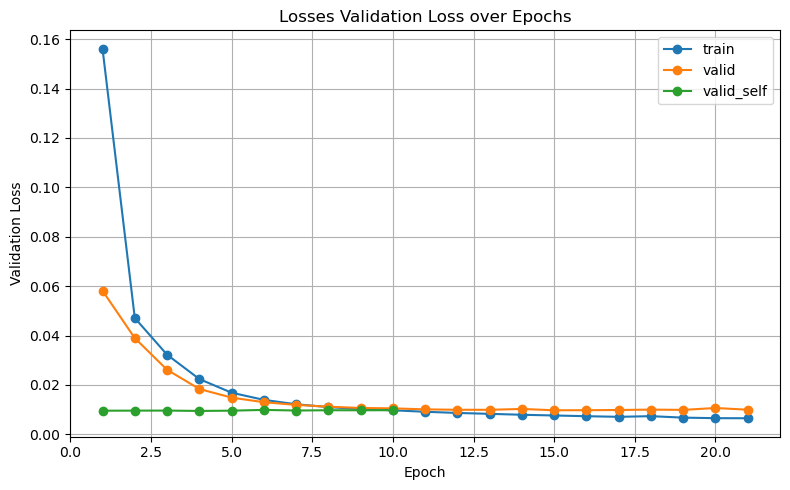

In [24]:
plot_results(results_dict, split="losses", metric="Validation Loss")

In [25]:
model.eval()
with torch.no_grad():
    test_x = torch.from_numpy(test_doc_emb).float().to(device)
    test_logits = model(test_x)
    test_probs = torch.sigmoid(test_logits).cpu().numpy()   # (N_test, NUM_CLASSES)

TOP_K_PRED = 3
THRESHOLD = 0.0

topk_indices = np.argsort(-test_probs, axis=1)[:, :TOP_K_PRED]  # (N_test, K)

labels_str_list = []

for i in range(test_probs.shape[0]):
    selected = []

    for cid in topk_indices[i]:
        if test_probs[i, cid] >= THRESHOLD:
            selected.append(str(int(cid)))

    # fallback: 아무것도 없으면 top-1은 무조건 포함
    if len(selected) == 0:
        selected.append(str(int(topk_indices[i, 0])))

    labels_str_list.append(",".join(selected))

submission = pd.DataFrame({
    "id": np.arange(len(test_doc_emb)).astype(str),
    "labels": labels_str_list
})


SUBMISSION_PATH = Path("Outputs") / "mpnet_gat_self.csv"
SUBMISSION_PATH.parent.mkdir(exist_ok=True, parents=True)
submission.to_csv(SUBMISSION_PATH, index=False, encoding="utf-8")

print("Saved submission to:", SUBMISSION_PATH)

Saved submission to: Outputs/mpnet_gat_self.csv
